# Customer Sales Prediction Using Advertising Spend

## Business Case
A retail/consumer products company wants to understand how advertising spend across different channels impacts sales performance. Leadership needs a predictive model that can estimate future sales and identify which advertising channels drive the strongest return.

## Dataset
This notebook is designed for the Kaggle **Advertising Sales Dataset**, which contains advertising spend across **TV, Radio, and Newspaper** channels and corresponding **Sales** revenue.

Kaggle source: https://www.kaggle.com/datasets/yasserh/advertising-sales-dataset

## Objective
- Analyze the relationship between advertising channels and sales.
- Build a regression model to predict sales.
- Evaluate model performance using MAE, RMSE, and R².
- Provide business recommendations based on model findings.

## 1. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

In [9]:
import os

possible_files = [
    'data/Advertising Budget and Sales.csv',
    'data/Advertising.csv',
    'Advertising Budget and Sales.csv',
    'Advertising.csv'
]

csv_path = None
for file in possible_files:
    if os.path.exists(file):
        csv_path = file
        break

if csv_path is None:
    print('Dataset file not found. Please download the Kaggle dataset and place the CSV in the data/ folder.')
else:
    df = pd.read_csv(csv_path)
    print(f'Dataset loaded from: {csv_path}')
    display(df.head())

Dataset loaded from: data/Advertising Budget and Sales.csv


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## 3. Initial Data Review

In [13]:
# Run this cell after the dataset is loaded
print('Shape:', df.shape)
print('Columns:')
print(df.columns)
print('Missing values:')
print(df.isnull().sum())
print('Summary statistics:')
display(df.describe())

Shape: (200, 5)
Columns:
Index(['Unnamed: 0', 'TV Ad Budget ($)', 'Radio Ad Budget ($)',
       'Newspaper Ad Budget ($)', 'Sales ($)'],
      dtype='object')
Missing values:
Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64
Summary statistics:


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


## 4. Data Cleaning
The Kaggle dataset may include an unnamed index column. This section removes unnecessary columns and standardizes column names.

In [15]:
# Drop index-like columns if present
for col in df.columns:
    if 'unnamed' in col.lower():
        df = df.drop(columns=[col])

# Standardize column names
clean_columns = []
for col in df.columns:
    clean_columns.append(col.strip().lower().replace(' ', '_'))
df.columns = clean_columns

print(df.columns)
display(df.head())

Index(['tv_ad_budget_($)', 'radio_ad_budget_($)', 'newspaper_ad_budget_($)',
       'sales_($)'],
      dtype='object')


,tv_ad_budget_($),radio_ad_budget_($),newspaper_ad_budget_($),sales_($)
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 5. Exploratory Data Analysis (EDA)
This section helps identify relationships between advertising channels and sales.

,tv_ad_budget_($),radio_ad_budget_($),newspaper_ad_budget_($),sales_($)
tv_ad_budget_($),1.000000,0.054809,0.056648,0.782224
radio_ad_budget_($),0.054809,1.000000,0.354104,0.576223
newspaper_ad_budget_($),0.056648,0.354104,1.000000,0.228299
sales_($),0.782224,0.576223,0.228299,1.000000


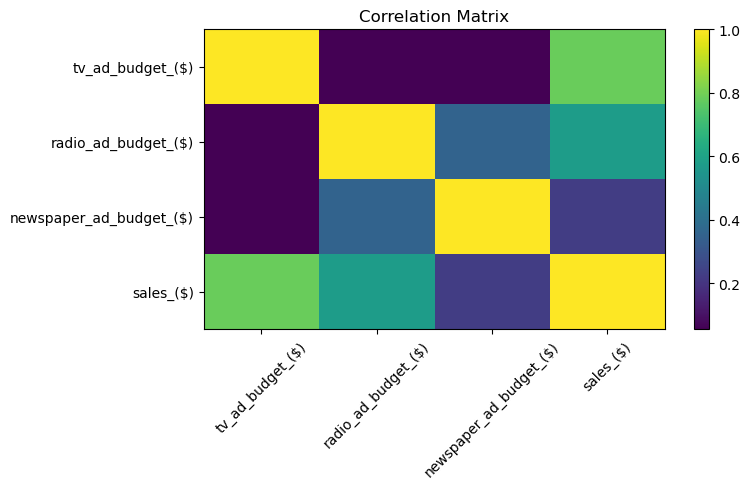

In [17]:
# Correlation matrix
correlation = df.corr(numeric_only=True)
display(correlation)

plt.figure(figsize=(8, 5))
plt.imshow(correlation, aspect='auto')
plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)
plt.colorbar()
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

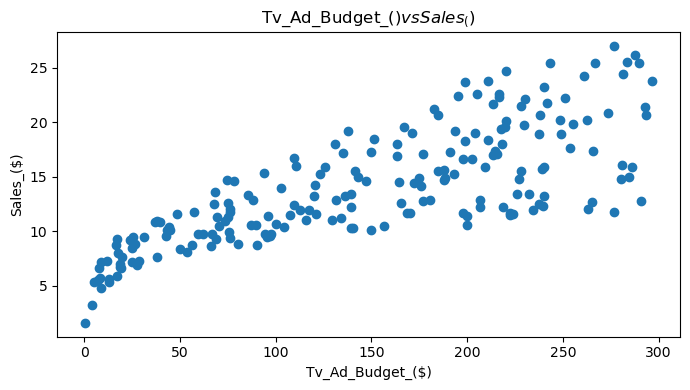

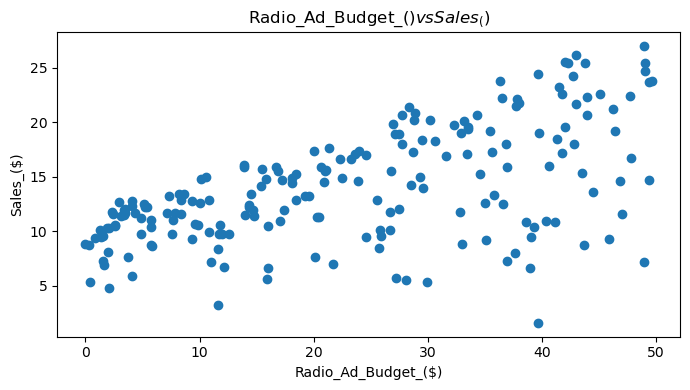

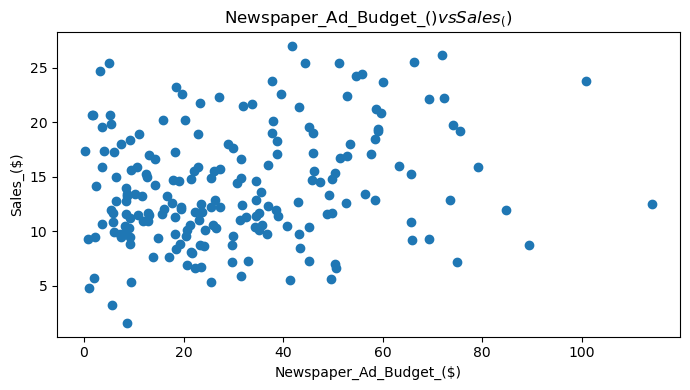

In [19]:
# Scatter plots for each advertising channel against sales
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

target_col = 'sales' if 'sales' in df.columns else numeric_cols[-1]
feature_cols = [col for col in numeric_cols if col != target_col]

for col in feature_cols:
    plt.figure(figsize=(7, 4))
    plt.scatter(df[col], df[target_col])
    plt.xlabel(col.title())
    plt.ylabel(target_col.title())
    plt.title(f'{col.title()} vs {target_col.title()}')
    plt.tight_layout()
    plt.show()

## 6. Model Development
We use Multiple Linear Regression to predict sales based on advertising spend across channels.

In [21]:
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print('Model training complete.')

Model training complete.


## 7. Model Evaluation
We evaluate the model using:

- **MAE**: Average prediction error
- **RMSE**: Penalizes larger errors
- **R²**: Explains how much variance in sales is captured by the model

In [24]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'R-squared (R²): {r2:.2f}')

Mean Absolute Error (MAE): 1.46
Root Mean Squared Error (RMSE): 1.78
R-squared (R²): 0.90


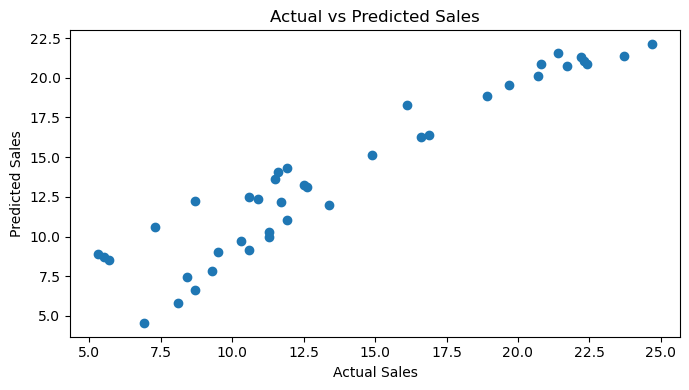

In [26]:
plt.figure(figsize=(7, 4))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')
plt.tight_layout()
plt.show()

## 8. Feature Impact Analysis
Model coefficients help explain how each advertising channel contributes to predicted sales.

In [ ]:
coefficients = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

display(coefficients)

plt.figure(figsize=(7, 4))
plt.bar(coefficients['Feature'], coefficients['Coefficient'])
plt.xlabel('Advertising Channel')
plt.ylabel('Coefficient')
plt.title('Impact of Advertising Channels on Sales')
plt.tight_layout()
plt.show()

## 9. Business Recommendations

Based on the regression model and feature coefficients:

1. **Prioritize high-impact channels**: Increase investment in channels with the strongest positive relationship to sales.
2. **Optimize low-performing channels**: Reassess spend in channels with weaker or negative impact.
3. **Use predictive planning**: Apply the model during budget planning to forecast sales under different advertising scenarios.
4. **Improve future modeling**: Add more variables such as seasonality, region, product category, promotions, and customer demographics.

## Conclusion
This project demonstrates how regression modeling can support business decision-making by predicting sales and identifying the advertising channels that most influence revenue.

## 10. Sample Prediction
Use this section to estimate sales under a proposed advertising budget scenario.

In [ ]:
# Replace values below with your proposed budget/spend values
sample_input = pd.DataFrame([[100, 25, 15]], columns=feature_cols[:3])

# If dataset has more or fewer features, create a matching sample automatically
if len(feature_cols) != 3:
    sample_input = pd.DataFrame([X.mean().values], columns=feature_cols)

predicted_sales = model.predict(sample_input)[0]
print(f'Predicted Sales: {predicted_sales:.2f}')
display(sample_input)